In [1]:
# https://www.kaggle.com/competitions/face-matching-aicc-round-2/

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image
import torch
import torch.nn.functional as F

In [2]:
ref = pd.read_csv("/kaggle/input/face-matching-aicc-round-2/face-matching/ref_img.csv")

ref['ref_img'] = ref['ref_img'].map(lambda x: f'{x:03}')

imgs_dir = "/kaggle/input/face-matching-aicc-round-2/face-matching/images"

ref.head()

,ref_img
0,048
1,025
2,095
3,043
4,105


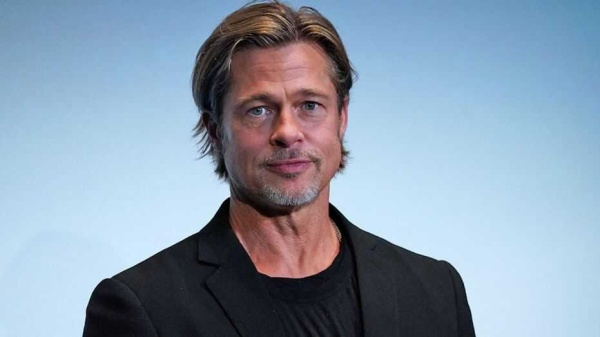

In [3]:
Image.open(os.path.join(imgs_dir, ref['ref_img'][1] + '.jpg'))

In [4]:
device = torch.device("cuda" if torch.cuda.is_available else "cpu")
device

device(type='cuda')

In [5]:
# Load model directly
from transformers import CLIPProcessor, CLIPModel

model_checkpoint = 'openai/clip-vit-large-patch14'

processor = CLIPProcessor.from_pretrained(model_checkpoint, return_tensors='pt', use_fast=True)
model = CLIPModel.from_pretrained(model_checkpoint)
model = model.to(device).eval()

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
def get_embs(paths):
    embs = []
    for img_path in tqdm(paths):
        inputs = processor(os.path.join(imgs_dir, img_path + '.jpg'))
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            output = model.get_image_features(**inputs)
        emb = output.last_hidden_state[0, 0, :].cpu()
        embs.append(emb)
    embs = torch.stack(embs)
    embs = F.normalize(embs, p=2, dim=1)
    return embs

In [7]:
ref_embs = get_embs(ref['ref_img'])

X_paths = np.array([p[:-4] for p in os.listdir(imgs_dir) if p[:-4] not in ref['ref_img'].values])
X_embs = get_embs(X_paths)

ref_embs.shape, X_embs.shape

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/94 [00:00<?, ?it/s]

(torch.Size([15, 1024]), torch.Size([94, 1024]))

In [8]:
labels = torch.matmul(X_embs, ref_embs.T).argmax(dim=1)

answers = []
for _ in range(len(ref)):
    answers.append([])

for l, X_path in zip(labels, X_paths):
    answers[l].append(X_path.item())

In [9]:
for i in range(len(answers)):
    answers[i] = '|'.join(answers[i])

answers[:2]

['066|101|078|102', '033|094|067|006|042|086|005|041|032|083|040']

In [10]:
ref['photos'] = answers

ref.to_csv("submission.csv", index=False)

ref.head()

,ref_img,photos
0,048,066|101|078|102
1,025,033|094|067|006|042|086|005|041|032|083|040
2,095,014|047|072|021|045|097
3,043,034|027|001|057|093|050|052|023|013
4,105,024|100|058
